# Assignment 3

In [1]:
import requests

## Task 0

In [2]:
response = requests.post(
    "http://localhost:11434/api/generate",
    json={
        "model": "gemma3:1b",
        "prompt": "Explain machine learning in simple terms.",
        "stream": False
    }
)

print(response.json()["response"])

Okay, let’s break down machine learning in simple terms. Think of it like this:

**Instead of explicitly telling a computer *exactly* what to do in every situation, we teach it to learn from data.**

Here's a breakdown:

1. **Data is Key:** Machine learning starts with data. This could be anything – pictures, text, numbers, sounds – anything that has meaning.  The more data you give it, the better it can learn.

2. **Algorithms Learn:** We give the computer a "learning algorithm" – it's a set of instructions.  These algorithms look for patterns in the data.  They're like a detective looking for clues.

3. **Pattern Recognition:** The algorithm identifies patterns within the data. For example, in pictures, it might learn to recognize a cat by seeing many cats.  In numbers, it might learn to predict what comes next in a sequence.

4. **Prediction or Decision:** Once the algorithm has learned enough, it can use what it’s learned to make predictions or decisions about new, unseen data. 

*

In [3]:
response = requests.post(
    "http://localhost:11434/api/generate",
    json={
        "model": "gemma3:270m",
        "prompt": "What is AI?",
        "stream": False
    }
)

print(response.json()["response"])

AI stands for Artificial Intelligence. It's a broad field of research and development that aims to create machines that can perform tasks that typically require human intelligence.



### Ollama
Ollama was installed and connected locally.

The gemma3:270m model was loaded and tested with a simple prompt.

The gemma3:1b model was also loaded and tested. I used the 1b version instead of the 4b version because the assignment allowed using 1b if 4b was too slow.

Both models returned valid responses.

## Task 1

In [4]:
import pandas as pd
import csv

pd.read_csv("emails.csv", sep=";")

rows = []

with open("emails.csv", newline="", encoding="utf-8") as file:
    reader = csv.reader(file)
    header = next(reader)

    for row in reader:
        rows.append(" ".join(row).strip())

emails = pd.DataFrame(rows, columns=["headline"])

emails

,headline
0,URGENT: Your account will be suspended within ...
1,Congratulations! You have won a 1000€ gift car...
2,Hot singles in your area are waiting to meet y...
3,Re: Inheritance transfer of 4.5M USD pending y...
4,Meeting agenda for Thursday's project review
5,Q3 budget report attached please review by Fr...
6,Reminder: Annual performance review scheduled ...
7,Updated draft of the manuscript comments welcome
8,Quick question about last week
9,Following up


### 1a


In [5]:
import requests

def classify_email(headline, model="gemma3:1b"):
    prompt = f"""
Classify the following email headline into one of these categories:
- spam
- work
- unknown

ONLY return the category word, nothing else.

Email: "{headline}"
"""

    response = requests.post(
        "http://localhost:11434/api/generate",
        json={
            "model": model,
            "prompt": prompt,
            "stream": False
        }
    )

    result = response.json()["response"].strip().lower()

    # safety cleanup (if model writes extra text)
    if "spam" in result:
        return "spam"
    elif "work" in result:
        return "work"
    else:
        return "unknown"

In [6]:
classify_email("URGENT: Your account will be suspended within 24 hours")

'spam'

### 1b

In [7]:
emails["gemma3_270m"] = emails["headline"].apply(
    lambda headline: classify_email(headline, model="gemma3:270m")
)

emails

,headline,gemma3_270m
0,URGENT: Your account will be suspended within ...,unknown
1,Congratulations! You have won a 1000€ gift car...,spam
2,Hot singles in your area are waiting to meet y...,work
3,Re: Inheritance transfer of 4.5M USD pending y...,spam
4,Meeting agenda for Thursday's project review,work
5,Q3 budget report attached please review by Fr...,spam
6,Reminder: Annual performance review scheduled ...,work
7,Updated draft of the manuscript comments welcome,work
8,Quick question about last week,spam
9,Following up,spam


### 1c

In [8]:
emails["gemma3_1b"] = emails["headline"].apply(
    lambda headline: classify_email(headline, model="gemma3:1b")
)

emails

,headline,gemma3_270m,gemma3_1b
0,URGENT: Your account will be suspended within ...,unknown,spam
1,Congratulations! You have won a 1000€ gift car...,spam,spam
2,Hot singles in your area are waiting to meet y...,work,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,work
4,Meeting agenda for Thursday's project review,work,work
5,Q3 budget report attached please review by Fr...,spam,work
6,Reminder: Annual performance review scheduled ...,work,work
7,Updated draft of the manuscript comments welcome,work,work
8,Quick question about last week,spam,unknown
9,Following up,spam,work


Comparison between models:

The gemma3:1b model appears to give more consistent and reasonable classifications compared to the smaller gemma3:270m model.

The 270m model misclassifies some obvious spam or work emails, for example:
- "Meeting agenda for Thursday's project review" was classified as spam by the 270m model but as work by the 1b model.
- Several vague emails like "Following up" and "Are you available?" were classified as spam by the 270m model, while the 1b model classified them as work or unknown.

The 1b model seems better at handling uncertain or vague headlines, often choosing "unknown" instead of forcing a wrong classification.

Overall, the larger model (1b) performs better and is more reliable, although it is slightly slower.

### 1d

In [9]:
comparison_df = emails[["headline"]].copy()

# Repeat classification 3 times with gemma3:270m
for run in range(1, 4):
    comparison_df[f"270m_run_{run}"] = comparison_df["headline"].apply(
        lambda headline: classify_email(headline, model="gemma3:270m")
    )

# Repeat classification 3 times with gemma3:1b
for run in range(1, 4):
    comparison_df[f"1b_run_{run}"] = comparison_df["headline"].apply(
        lambda headline: classify_email(headline, model="gemma3:1b")
    )

comparison_df

,headline,270m_run_1,270m_run_2,270m_run_3,1b_run_1,1b_run_2,1b_run_3
0,URGENT: Your account will be suspended within ...,unknown,unknown,unknown,spam,spam,spam
1,Congratulations! You have won a 1000€ gift car...,spam,spam,spam,spam,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,work,work,spam,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,work,unknown,work,work,work
4,Meeting agenda for Thursday's project review,work,work,work,work,work,work
5,Q3 budget report attached please review by Fr...,spam,work,spam,work,work,work
6,Reminder: Annual performance review scheduled ...,work,work,work,work,work,work
7,Updated draft of the manuscript comments welcome,work,work,spam,work,work,work
8,Quick question about last week,spam,spam,spam,unknown,unknown,unknown
9,Following up,spam,spam,spam,work,work,work


The results show that the model outputs can vary between runs, especially for vague email headlines. This happens because language models generate probabilistic outputs and uncertain headlines do not contain enough context for a clear classification.

The larger gemma3:1b model appears more stable and gives more reasonable classifications than gemma3:270m, but some variation can still occur.

## Task 2

In [10]:
rows = []

with open("news.csv", newline="", encoding="utf-8") as file:
    reader = csv.reader(file)
    header = next(reader)

    for row in reader:
        rows.append(" ".join(row).strip())

news = pd.DataFrame(rows, columns=["headline"])

news

,headline
0,Nordion Industries beats Q1 earnings estimates...
1,Helvora Pharmaceuticals misses earnings foreca...
2,Aurelis Bank reports steady quarterly profit ...
3,Veridyne Logistics to acquire rival Trantec in...
4,Antitrust regulators block proposed merger bet...
5,Kestrel Semiconductor confirms early-stage mer...
6,New EU AI Act compliance rules expected to rai...
7,Finnish FSA grants Norvik Capital expanded lic...
8,Eurozone inflation cools to 2.1% easing press...
9,Rising interest rates weigh on Tessaro Real Es...


### Task 2a

In [11]:
import requests
import json

def classify_news(headline, model="gemma3:1b"):
    prompt = f"""
classifying the following financial news headline.

Choose ONE topic:
earnings, mergers, regulation, macroeconomics

Choose ONE sentiment:
positive, negative, neutral

Respond ONLY with valid JSON.
No explanation.

Example:
{{"topic": "earnings", "sentiment": "positive"}}

Headline: "{headline}"
"""

    response = requests.post(
        "http://localhost:11434/api/generate",
        json={
            "model": model,
            "prompt": prompt,
            "stream": False
        }
    )

    result = response.json()["response"].strip()

    # 🔥 Extract JSON safely
    try:
        start = result.find("{")
        end = result.rfind("}") + 1
        json_str = result[start:end]
        return json.loads(json_str)
    except:
        return {"topic": "unknown", "sentiment": "unknown"}

In [12]:
classify_news(news["headline"][0])

{'topic': 'earnings', 'sentiment': 'positive'}

### Task 2b

In [13]:
results = news["headline"].apply(
    lambda headline: classify_news(headline, model="gemma3:1b")
)

results_df = pd.DataFrame(results.tolist())

news_results = pd.concat([news, results_df], axis=1)

news_results

,headline,topic,sentiment
0,Nordion Industries beats Q1 earnings estimates...,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,mergers,negative
2,Aurelis Bank reports steady quarterly profit ...,earnings,positive
3,Veridyne Logistics to acquire rival Trantec in...,mergers,positive
4,Antitrust regulators block proposed merger bet...,mergers,negative
5,Kestrel Semiconductor confirms early-stage mer...,mergers,positive
6,New EU AI Act compliance rules expected to rai...,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,mergers,positive
8,Eurozone inflation cools to 2.1% easing press...,macroeconomics,positive
9,Rising interest rates weigh on Tessaro Real Es...,macroeconomics,negative


### Task 2c

ChatGPT
| headline                                                | topic          | sentiment |
| ------------------------------------------------------- | -------------- | --------- |
| Nordion Industries beats Q1 earnings estimates          | earnings       | positive  |
| Helvora Pharmaceuticals misses earnings forecasts       | earnings       | negative  |
| Aurelis Bank reports steady quarterly profit            | earnings       | positive  |
| Veridyne Logistics to acquire rival Trantec             | mergers        | positive  |
| Antitrust regulators block proposed merger              | mergers        | negative  |
| Kestrel Semiconductor confirms early-stage merger talks | mergers        | neutral   |
| New EU AI Act compliance rules expected to raise costs  | regulation     | negative  |
| Finnish FSA grants Norvik Capital expanded license      | regulation     | positive  |
| Eurozone inflation cools to 2.1%                        | macroeconomics | positive  |
| Rising interest rates weigh on Tessaro Real Estate      | macroeconomics | negative  |


### Comparison with browser-based LLM

The browser-based LLM produced more accurate topic classifications than the local gemma3:1b model.

The local model classified many headlines as "mergers", even when the correct topic was "earnings" or "regulation". For example, earnings-related headlines and regulatory news (such as the EU AI Act) were misclassified.

The browser-based LLM correctly distinguishes between different financial topics and provides more precise classifications.

Sentiment predictions from both models were generally reasonable, but the topic classification was significantly better in the browser-based model.

Overall, the browser-based LLM is more accurate, likely due to being a larger and more advanced model compared to the local gemma3:1b model.

## Task 3

In [14]:
rows = []

with open("bank-additional.csv", newline="", encoding="utf-8") as file:
    reader = csv.reader(file)
    header = next(reader)

    for row in reader:
        rows.append(" ".join(row).strip())

news = pd.DataFrame(rows, columns=["headline"])

news

,headline
0,"30;""blue-collar"";""married"";""basic.9y"";""no"";""ye..."
1,"39;""services"";""single"";""high.school"";""no"";""no""..."
2,"25;""services"";""married"";""high.school"";""no"";""ye..."
3,"38;""services"";""married"";""basic.9y"";""no"";""unkno..."
4,"47;""admin."";""married"";""university.degree"";""no""..."
...,...
4114,"30;""admin."";""married"";""basic.6y"";""no"";""yes"";""y..."
4115,"39;""admin."";""married"";""high.school"";""no"";""yes""..."
4116,"27;""student"";""single"";""high.school"";""no"";""no"";..."
4117,"58;""admin."";""married"";""high.school"";""no"";""no"";..."


### Task 3a

In [16]:
bank = pd.read_csv("bank-additional.csv", sep=";")
display(bank.head())

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [ ]:
bank.info()

<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   float64
 18 

In [ ]:
bank.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [ ]:
bank["y"].value_counts()

y
no     3668
yes     451
Name: count, dtype: int64

In [ ]:
bank["y"].value_counts(normalize=True) * 100

y
no     89.05074
yes    10.94926
Name: proportion, dtype: float64

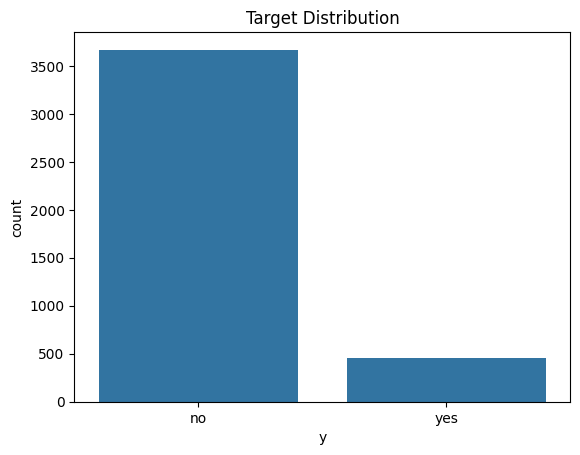

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=bank, x="y")
plt.title("Target Distribution")
plt.show()

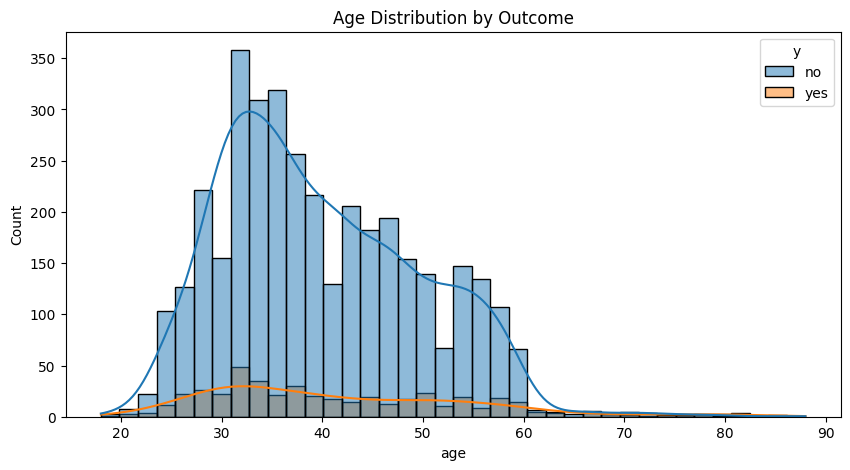

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data=bank, x="age", hue="y", kde=True)
plt.title("Age Distribution by Outcome")
plt.show()

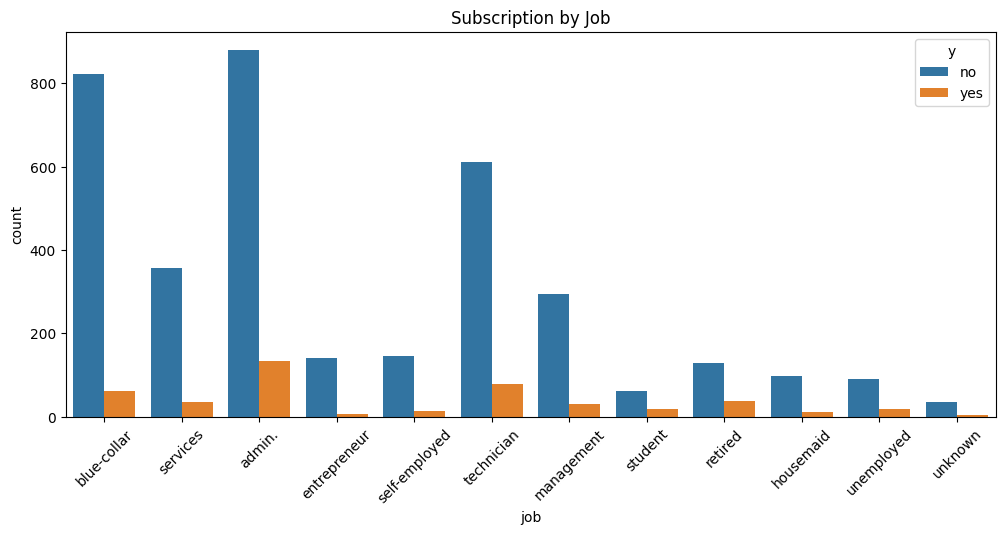

In [ ]:
plt.figure(figsize=(12,5))
sns.countplot(data=bank, x="job", hue="y")
plt.xticks(rotation=45)
plt.title("Subscription by Job")
plt.show()

The dataset contains customer information from a bank marketing campaign. The target variable is y, which indicates whether a client subscribed to a term deposit. The dataset includes both numerical and categorical variables. The target variable is imbalanced, with more "no" than "yes" cases. This suggests that preprocessing and careful model evaluation are important.

### Task 3b

In [ ]:
import pandas as pd

bank = pd.read_csv(
    "bank-additional.csv",
    sep=";"
)

In [ ]:
X = bank.drop("y", axis=1)
y = bank["y"]

In [ ]:
y = y.map({"yes": 1, "no": 0})

In [ ]:
categorical_cols = X.select_dtypes(include=["object", "string"]).columns
numerical_cols = X.select_dtypes(exclude=["object", "string"]).columns

categorical_cols, numerical_cols

(Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
        'month', 'day_of_week', 'poutcome'],
       dtype='str'),
 Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
        'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
       dtype='str'))

In [ ]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((3295, 53), (824, 53))

The data was preprocessed by separating the features from the target variable. The target variable y was converted from yes/no into binary values where yes = 1 and no = 0. Categorical variables were transformed using one-hot encoding, while numerical variables were scaled using StandardScaler. The data was then split into training and test sets using stratification because the target variable is imbalanced.


### Task 3c

This is a classification task because the target variable y has two classes: yes and no. I chose Logistic Regression as a simple baseline model, Random Forest because it can model non-linear relationships, and K-Nearest Neighbors because it is a different distance-based classification method.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight="balanced"),
    "KNN": KNeighborsClassifier(n_neighbors=7)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df

,model,accuracy,precision,recall,f1_score
0,Logistic Regression,0.876214,0.462963,0.833333,0.595238
1,Random Forest,0.911408,0.593407,0.600000,0.596685
2,KNN,0.896845,0.555556,0.277778,0.370370


In [ ]:
tuned_models = {
    "Logistic Regression tuned": LogisticRegression(C=0.1, max_iter=1000, class_weight="balanced"),
    "Random Forest tuned": RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_split=5, random_state=42, class_weight="balanced"),
    "KNN tuned": KNeighborsClassifier(n_neighbors=11)
}

tuned_results = []

for name, model in tuned_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    tuned_results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred)
    })

tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df

,model,accuracy,precision,recall,f1_score
0,Logistic Regression tuned,0.875000,0.460123,0.833333,0.592885
1,Random Forest tuned,0.891990,0.503937,0.711111,0.589862
2,KNN tuned,0.896845,0.567568,0.233333,0.330709


I adjusted key hyperparameters for the three models. For Logistic Regression, I changed the regularization strength C. For Random Forest, I changed the number of trees, maximum depth and minimum samples split. For KNN, I changed the number of neighbors. The goal was to improve performance, especially the F1-score, because the dataset is imbalanced.

The results show that Random Forest performs best overall, with the highest accuracy and a more balanced precision and recall compared to the other models. Logistic Regression has high recall but lower precision, meaning it identifies many positive cases but also produces more false positives. KNN performs worse, especially in recall, indicating that it struggles to correctly identify positive cases.

After tuning, the performance changes slightly, but Random Forest still remains the most balanced model. Given the class imbalance in the dataset, F1-score is an important metric, and Random Forest provides the best trade-off between precision and recall.


Accuracy alone is not sufficient for this task due to class imbalance. Therefore, F1-score is a more reliable metric for evaluating model performance.

### 3d

In [ ]:
models["Logistic Regression"] = LogisticRegression(
    max_iter=10000,
    solver="liblinear",
    class_weight="balanced"
)

In [ ]:
from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_encoded,
        y,
        cv=5,
        scoring="f1"
    )

    cv_results.append({
        "model": name,
        "cv_f1_mean": scores.mean(),
        "cv_f1_std": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,model,cv_f1_mean,cv_f1_std
0,Logistic Regression,0.572003,0.020485
1,Random Forest,0.582805,0.025902
2,KNN,0.492638,0.034363


Cross-validation was used to compare the models more robustly than a single train-test split. The results show that Random Forest achieved the highest average F1-score, followed by Logistic Regression and KNN. This suggests that Random Forest performs best across multiple folds.

Cross-validation is preferred because it evaluates the model on several different train/test splits, giving a more reliable estimate of performance. The standard deviation shows how stable the model performance is across folds.

### Task 3e

The models were evaluated using accuracy, precision, recall, and F1-score. 
Since the dataset is imbalanced (many more "no" than "yes"), F1-score is the most important metric because it balances precision and recall.

Random Forest achieved the highest F1-score in both the train-test evaluation and cross-validation, indicating the best overall performance. It is able to capture non-linear relationships and interactions between features, which likely improves its predictive power.

Logistic Regression performed slightly worse but still provided stable and interpretable results. KNN had the lowest performance, especially in recall, meaning it struggled to correctly identify positive cases.

Based on these results, Random Forest is the best model for this task because it provides the highest and most consistent F1-score across different evaluation methods.

## Statement of AI use

I used ChatGPT to help with error messages and to fix small bugs